# Pruebas sobre el comportamiento de la red

En este documento se realizan varias pruebas sobre el comportamiento esperado de una red de neuronas, con una red similar al código de matlab que existe en el artículo de Izhikevich, 2003.

#### 1. Importar las librerías

In [47]:
import numpy as np

from src.Neurona import Neurona
from src.RedDeNeuronas import RedDeNeuronas
from src.Simulador import Simulador
from src.Visualizar import Visualizar

#### 2. Crear las constantes

In [48]:
# Número de pasos a simular
PASOS = 1000

# Paso temporal de la simulación
PASO_TEMPORAL = 1

# Número de neuronas de la red
NUM_NEURONAS = 1000
# Proporción de neuronas excitatorias, el resto serán inhibitorias
PROPORCION_EXC = 0.8

# Densidad de conexiones entre las neuronas de la red
DENSIDAD_CONEXIONES = 1     # Cualquier valor en el intervalo [0, 1]

# Parámetros de la red
BACKEND = "cupy"    # "numpy" o "cupy"
PRECISION = 32      # 32 o 64
SPARSE = True       # True o False

# Neuronas para la red
N_EXC = Neurona(a=0.02, b=0.2, c=-65, d=8, nombre="Neurona_excitatoria", es_excitatoria=True)
N_INH = Neurona(a=0.02, b=0.25, c=-65, d=2, nombre="Neurona_inhibitoria", es_excitatoria=False)

# Valores que determiann la aleatorización de los parámetros de las neuronas de la red
SEMILLA = 42
ALEAT_PARAM = {"excitatoria": (0, 0, 15, -6), "inhibitoria": (0.08, -0.05, 0, 0)}
ALEAT_CONEX = (0.5, 1)

# Valores máximos de corrientes de entrada
MAX_CORRIENTE_EXC = 5
MAX_CORRIENTE_INH = 2


#### 3. Crear la red

In [49]:
num_excitatorias = int(NUM_NEURONAS * PROPORCION_EXC)
num_inhibitorias = NUM_NEURONAS - num_excitatorias

max_conexiones = NUM_NEURONAS * (NUM_NEURONAS - 1)
num_conexiones = int(max_conexiones * DENSIDAD_CONEXIONES)

red = RedDeNeuronas(neuronas={N_EXC: num_excitatorias, N_INH: num_inhibitorias}, conexiones=num_conexiones, backend=BACKEND, precision=PRECISION,
                    sparse=SPARSE, semilla=SEMILLA, aleat_param=ALEAT_PARAM, aleat_conex=ALEAT_CONEX)

sim = Simulador(PASO_TEMPORAL, mostrar_progreso=True,medir_rendimiento=True, tamano_batch=100)
sim.cargar_red(red)
vis = Visualizar()

#### 4. Crear la corriente de entrada para la simulación

In [50]:
rng = np.random.RandomState(SEMILLA)
corriente_exc = MAX_CORRIENTE_EXC * rng.standard_normal((PASOS, num_excitatorias))
corriente_inh = MAX_CORRIENTE_INH * rng.standard_normal((PASOS, num_inhibitorias))
corriente = np.concatenate((corriente_exc, corriente_inh), axis=1)

#### 5. Ejecutar la simulación completa

In [51]:
tiempo = sim.simular(PASOS, corriente)
print(f"\nLa simulación teminó en {tiempo:.4f} s")

Simulando: 100%|██████████| 1000/1000 [00:02<00:00, 419.33pasos/s, CPU=100%, GPU=36%, RAM=473MB, VRAM=793MB]


La simulación teminó en 2.3718 s


#### 6. Cargar los resultados de la simulación al visualizador

In [52]:
vis.cargar_historial(historial=sim.historial)

#### 7. Mostrar el raster plot y la evolución temporal del potencial de membrana una neurona de la simulación

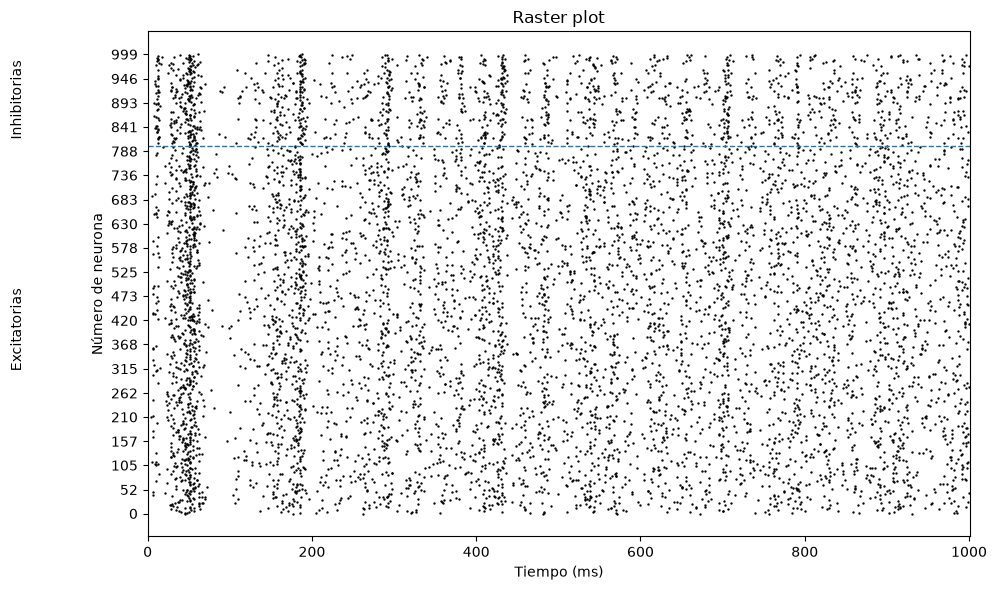

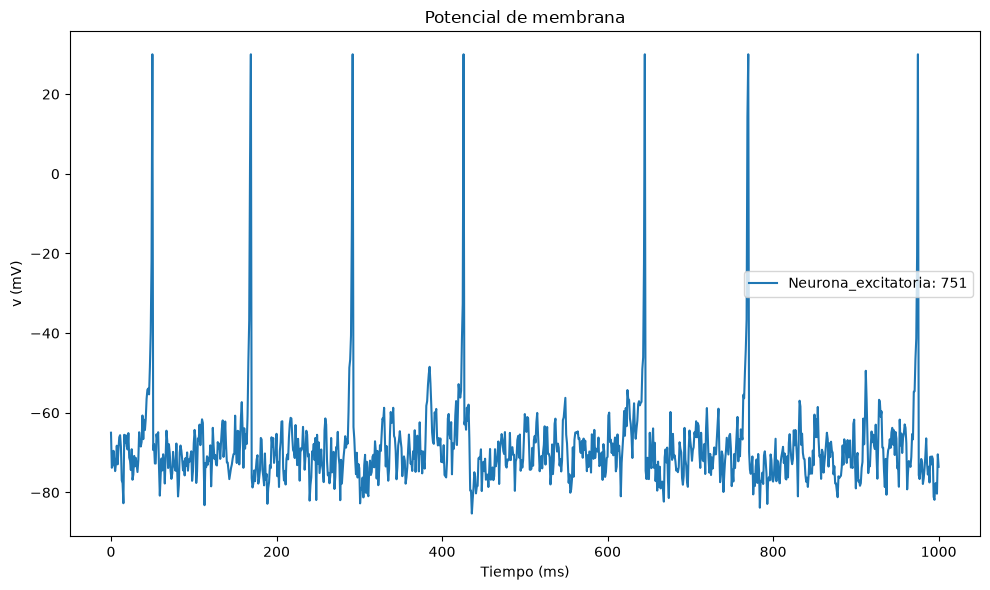

In [53]:
_ = vis.raster_plot()
n = rng.randint(0, NUM_NEURONAS + 1)
_ = vis.potencial_membrana(neuronas=n)

#### 8. Mostrar el resto de gráficas de la misma neurona del potencial de membrana

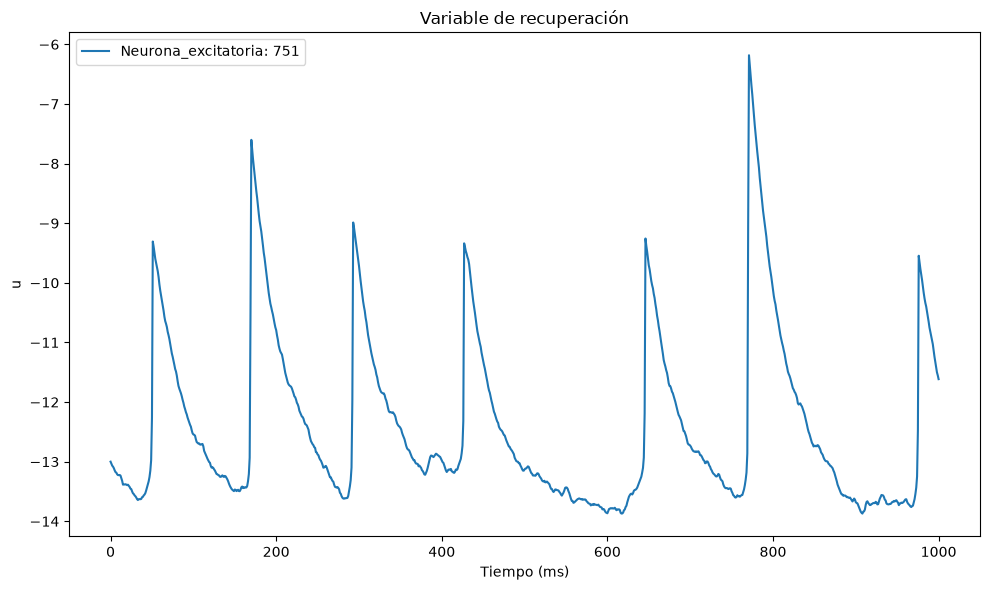

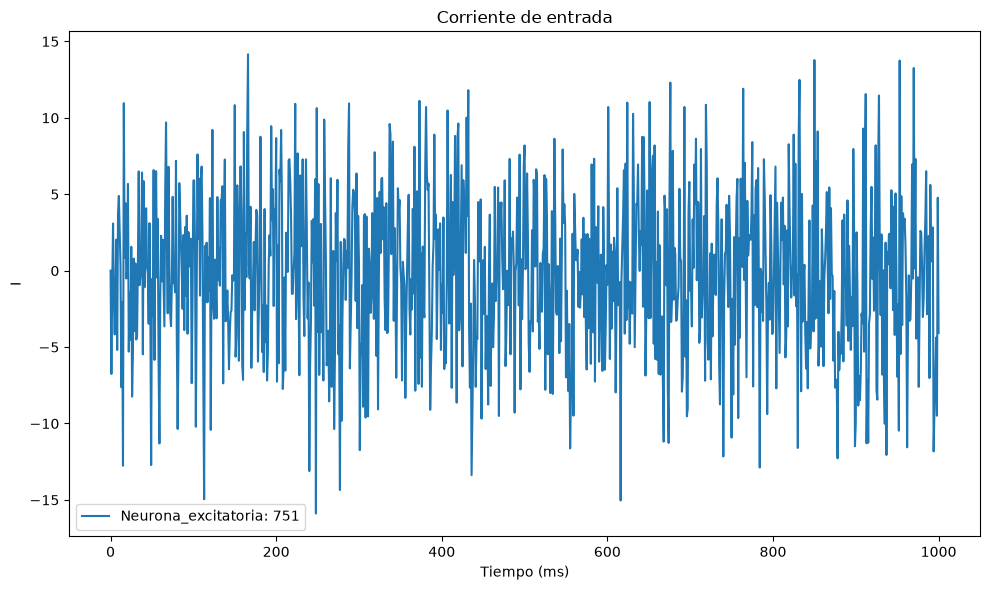

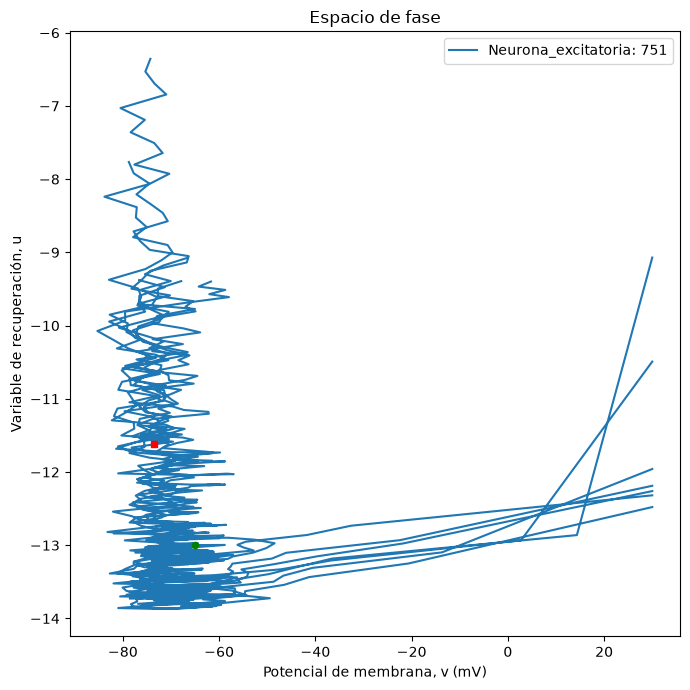

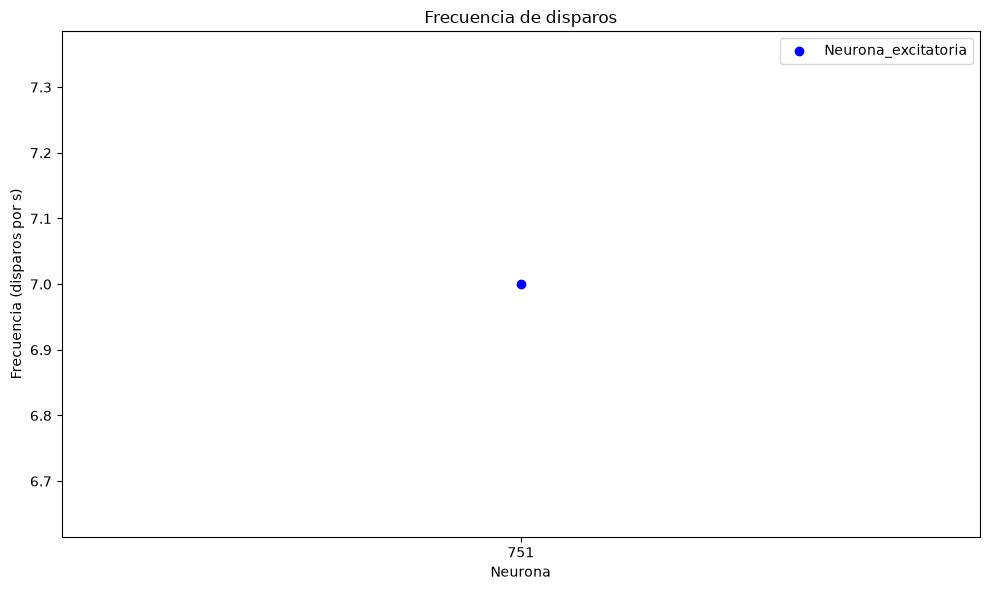

In [54]:
_ = vis.variable_recuperacion(neuronas=n)
_ = vis.corriente(neuronas=n)
_ = vis.espacio_fase(neuronas=n)
_ = vis.frecuencia_disparos(neuronas=n)

#### 9. Mostrar la frecuencia de disparos de toda la red

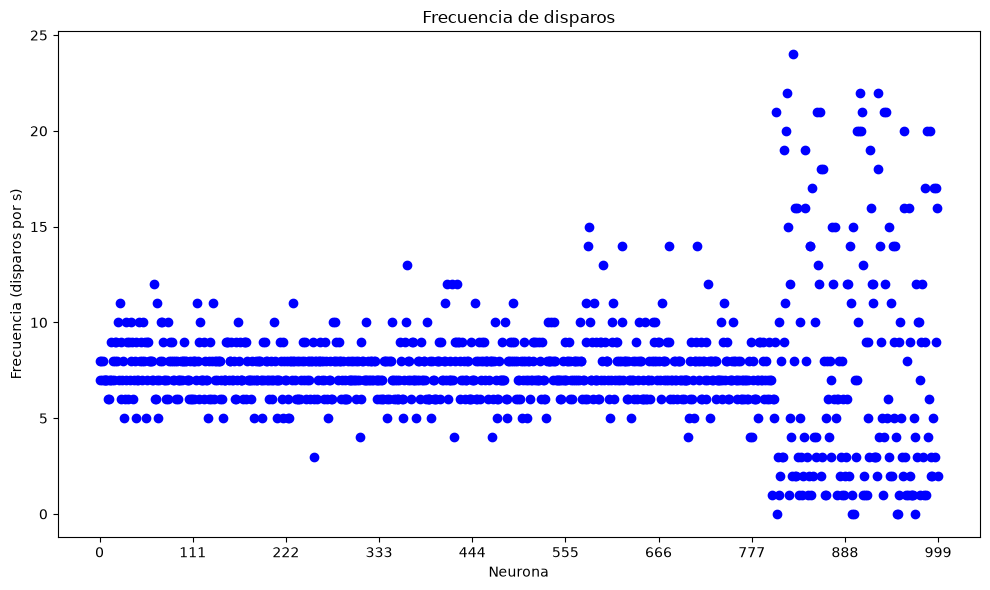

In [55]:
_ = vis.frecuencia_disparos(neuronas=None)